# The Annotated Diffusion Model

- Reference: https://huggingface.co/blog/annotated-diffusion

In [6]:
import math
from inspect import isfunction
from functools import partial

import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from einops import rearrange, reduce
from einops.layers.torch import Rearrange

import torch
from torch import nn, einsum
import torch.nn.functional as F

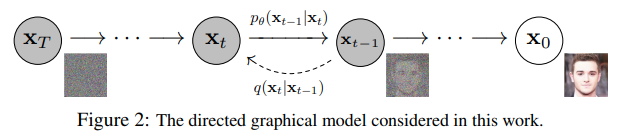

- (fixed Gaussian) forward process q
- (stochastic) reverse process p

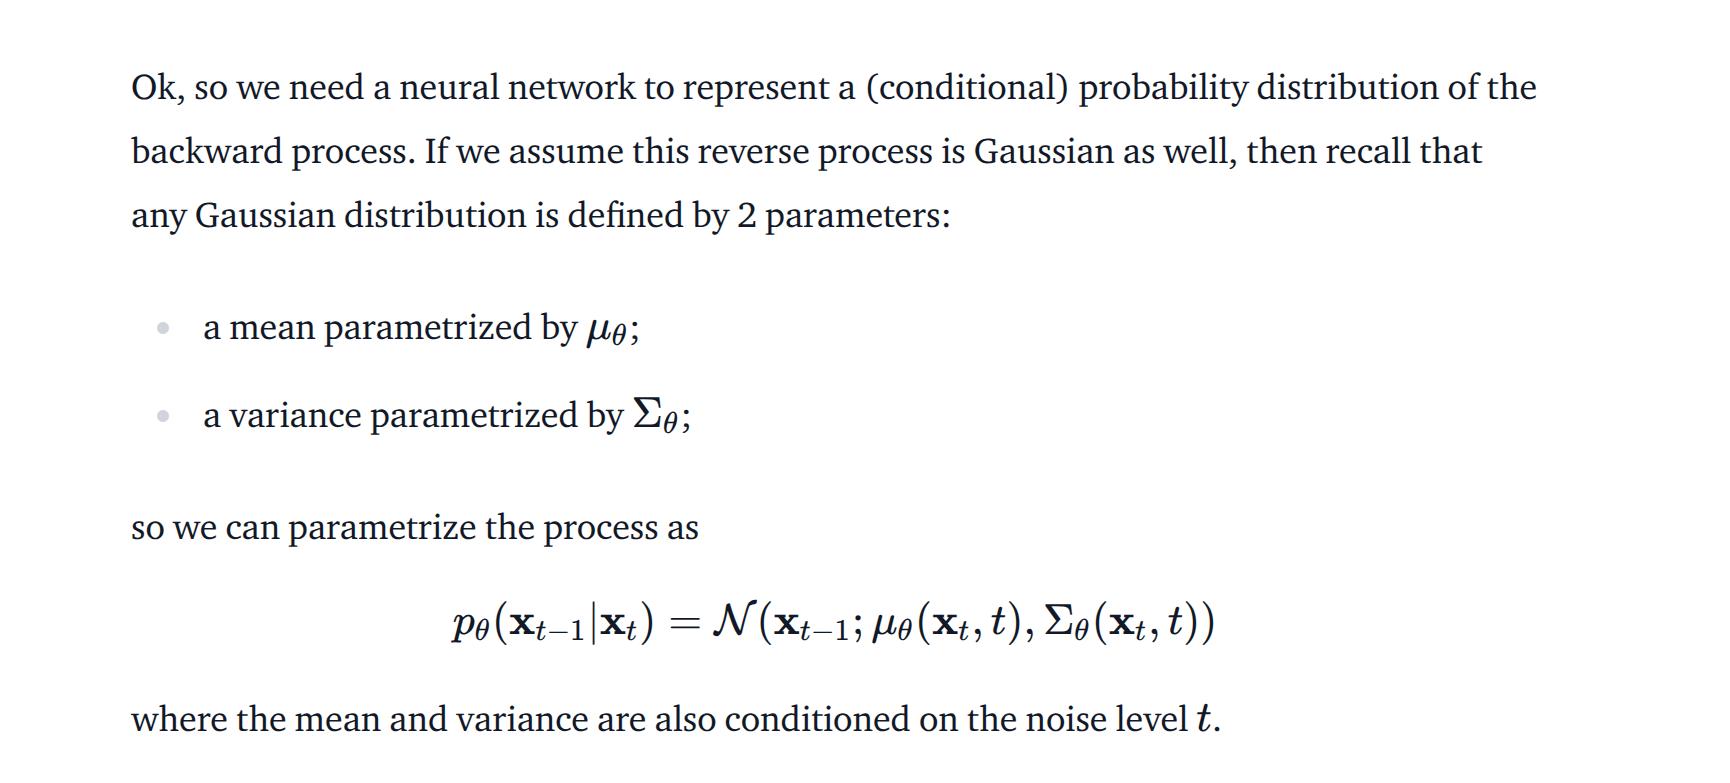

- Improved diffusion models 논문에서는 ddpm에서와 달리 variance도 학습될 수 있게 했다.

## The neural network

- noised image x를 입력받아 noise를 예측한다.
- 예측하는 noise는 input image와 동일한 사이즈(해상도)의 tensor임.
- DDPM 원논문에서는 U-Net을 사용하여 위 nn을 설계했음.
- U-Net을 사용하면 low-level feature와 global-level feature를 모두 볼 수 있어 context 파악에 도움이 된다.

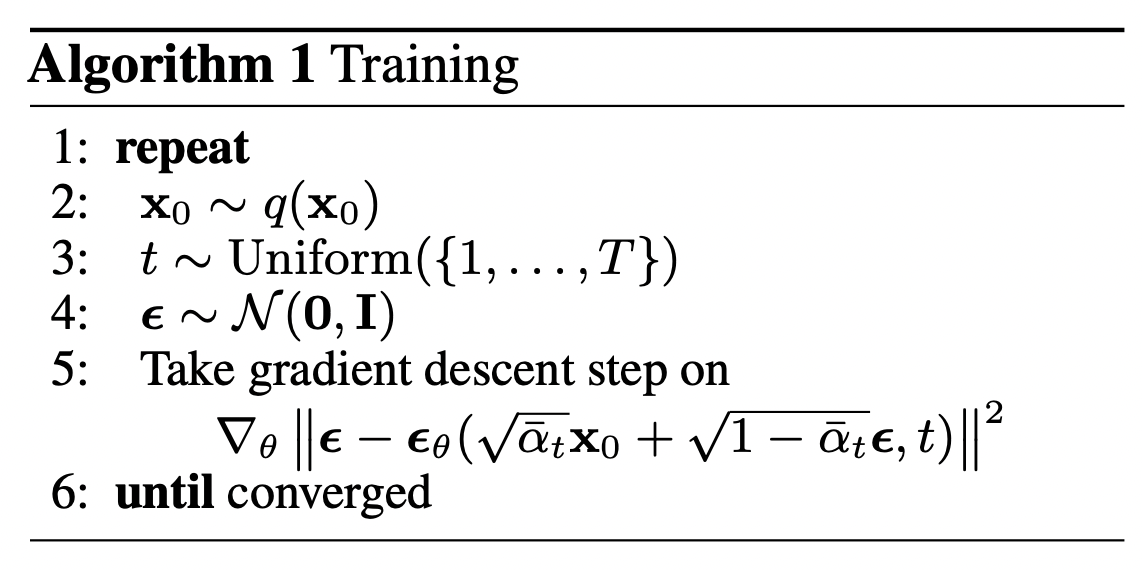


### Network Helpers

In [7]:
def exists(x):
    return x is not None

def default(val, d):
    if exists(val):
        return val
    return d() if isfunction(d) else d

def num_to_groups(num, divisor):
    """전체 작업량을 일정한 batch 크기로 나누고, 마지막 남은 개수까지 배열로 표현하기"""
    groups = num // divisor
    remainder = num % divisor
    arr = [divisor] * groups
    if remainder > 0:
        arr.append(remainder)
    return arr

class Residual(nn.Module):
    """Residual connection"""
    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x, *args, **kwargs):
        return self.fn(x, *args, **kwargs) + x # Residual(x) = fn(x) + x

def Upsample(dim, dim_out=None):
    """
    [B, C, H, W] -> [B, C_out, 2H, 2W]
    
    Upsample(64, 32)
      [B, 64, 16, 16] -> [B, 32, 32, 32]
    
    """
    return  nn.Sequential(
        nn.Upsample(scale_factor=2, mode="nearest"),
        nn.Conv2d(dim, default(dim_out, dim), 3, padding=1),
    )
   

def Downsample(dim, dim_out=None):
    """
    [B, C, H, W] -> [B, C * 4, H / 2, W / 2]

    No More Strided Convolutions or Pooling
    => Stride convoultion 연산이나 pooling 대신 먼저 Rearrange로
       각 2x2 공간 영역을 채널 방향으로 옮긴다
       그 다음 1x1 Conv2d로 채널 수를 조정
    """
    return nn.Sequential(
        Rearrange("b c (h p1) (w p2) -> b (c p1 p2) h w", p1=2, p2=2),
        nn.Conv2d(dim * 4, default(dim_out, dim), 1),
    )

### Position embeddings

- timestep에 대한 embedding

In [8]:
class SinusoidalPositionEmbeddings(nn.Module):
    """t를 U-Net에게 전달하기 위한 벡터로 변환"""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time): 
        device = time.device # diffusion의 timestep t
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(
            torch.arange(half_dim, device=device) * -embeddings 
            # half_dim 개수 만큼 배열을 만들고 log_e_10000 / half_dim -1를 배열에 곱함
        ) # exp(x) = e^x
        # -> [1, 0.1, 0.01, 0.001, ...]
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1) 
        # element-wise로 sin, cos 함수를 적용하고 마지막 차원 방향으로 이어 붙인다
        return embeddings

### ResNet block

- now we build the U-Net model (weight standardized version)

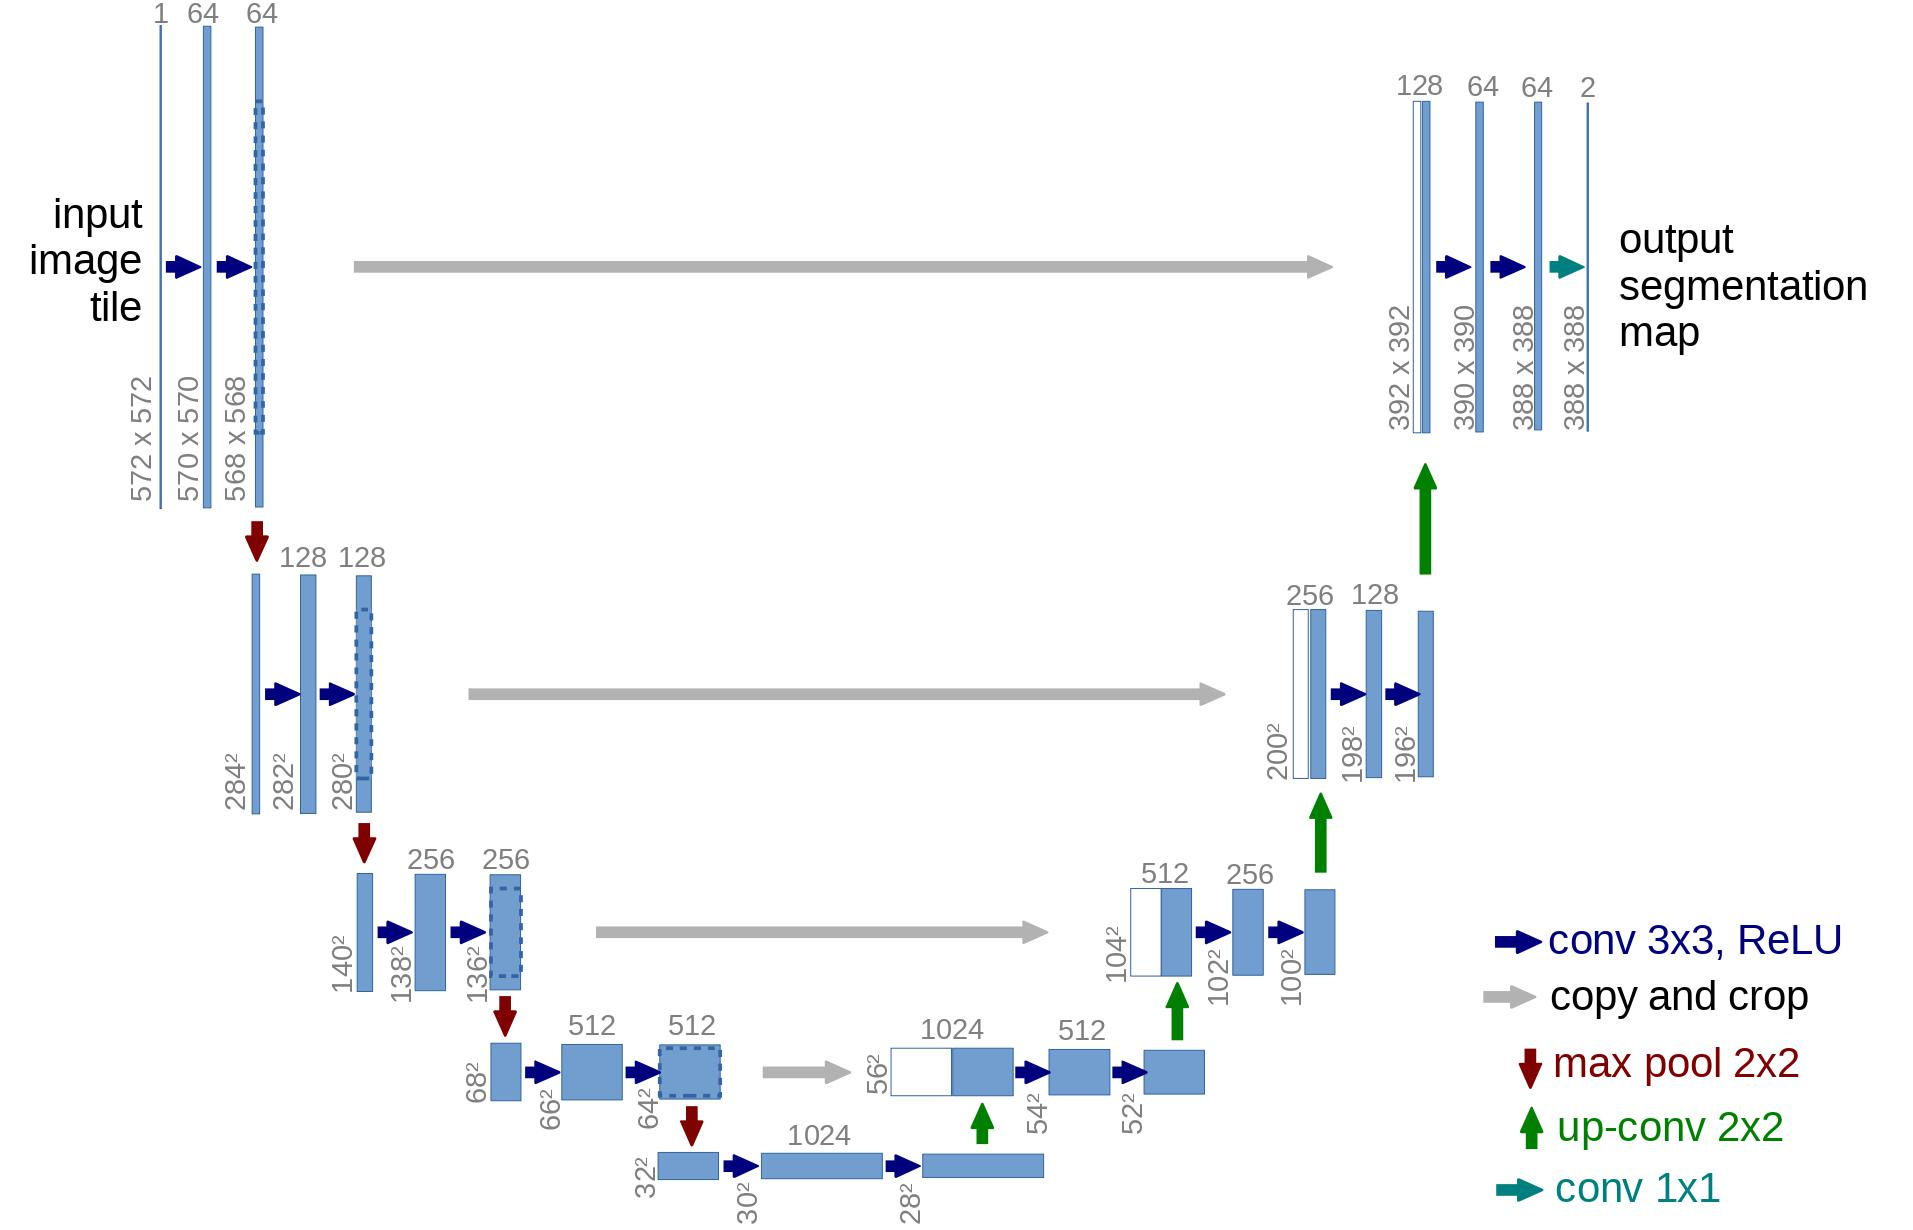

In [9]:
class WeightStandardizedConv2d(nn.Conv2d):
    """
    nn.Conv2d(
        in_channels,
        out_channels,
        kernel_size,
        stride=1,
        padding=0
    )
    """

    """
    https://arxiv.org/abs/1903.10520
    weight standardization purportedly works synergistically with group normalization
    """
    def forward(self, x):
        eps = 1e-5 if x.dtype == torch.float32 else 1e-3 # float32 숫자 정밀도 처리, epsilon(ε)

        """
        [o, i, h, w]
        o: output channel
        i: input channel
        h, w: convolution kernel의 height and weight
        """
        weight = self.weight

        mean = reduce(weight, "o ... -> o 1 1 1", "mean")
        """
        einops.reduce()
        "입력 형태 -> 출력 형태"

        o: output channel
        ...: 나머지 모든 차원, 즉 i, h, w를 크기가 1인 차원으로 남긴다. 평균을 내서.

        [o, i, h, w]
        -> [o, 1, 1, 1]
        """
        var = reduce(weight, "o ... -> o 1 1 1", partial(torch.var, unbiased=False)) 
        """
        functools.partial()
        
        unbiased=False: 
          - N-1이 아닌 N으로 나누어 분산을 계산해라
          - 학습 weight 전체를 정규화 하는 목적으로 False를 사용
        """
        normalized_weight = (weight - mean) * (var + eps).rsqrt()
        # rsqrt(): reciprocal square root
        # rsqrt(x) = 1 / sqrt(x)

        return F.conv2d(
            x,
            normalized_weight,
            self.bias,
            self.stride,
            self.padding,
            self.dilation,
            self.groups,
        )

class Block(nn.Module):
    def __init__(self, dim, dim_out, group=8):
        super().__init__()
        self.proj = WeightStandardizedConv2d(dim, dim_out, 3, padding=1)
        self.norm = nn.GroupNorm(groups, dim_out)
        self.act = nn.SiLU()

    def forward(self, x, scale_shift=None):
        x = self.proj(x)
        x = self.norm(x)

        if exists(scale_shift):
            scale, shift = scale_shift
            x = x * (scale + 1) + shift

        x = self.act(x)
        return x

class ResnetBlock(nn.Module):
    """https://arxiv.org/abs/1512.03385"""

    def __init__(self, dim, dim_out, *, time_emb_dim=None, groups=8):
        super().__init__()
        self.mlp = (
            nn.Sequential(nn.SiLU(), nn.Linear(time_emb_dim, dim_out * 2))
            if exists(time_emb_dim)
            else None
        )

        self.block1 = Block(dim, dim_out, groups=groups)
        self.block2 = Block(dim_out, dim_out, groups=groups)
        self.res_conv = nn.Conv2d(dim, dim_out, 1) if dim != dim_out else nn.Identity()

    def forward(self, x, time_emb=None):
        scale_shift = None
        if exists(self.mlp) and exists(time_emb):
            time_emb = self.mlp(time_emb)
            time_emb = rearrange(time_emb, "b c -> b c 1 1")
            """
            time_emb: [B, C, 1, 1]
            x:        [B, C, H, W]
            x + time_emb 시 형식이 올바름
            """
            scale_shift = time_emb.chunk(2, dim=1)

        h = self.block1(x, scale_shift=scale_shift)
        h = self.block2(h)
        return h + self.res_conv(x)

### Attention module

- DDPM에서 convolutional blocks 사이에 attention을 추가했음
- 특히, Transformer architecture에서 소개된 1. multi-head self-attention과 2. linear attention variant를 사용함

In [10]:
class Attention(nn.Module):
    def __init__(self, dim, heads=4, dim_head=32):
        super().__init__()
        self.scale = dim_head**-0.5
        self.heads = heads
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)
        self.to_out = nn.Conv2d(hidden_dim, dim, 1)

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=1)
        q, k, v = map(
            lambda t: rearrange(t, "b (h c) x y -> b h c (x y)", h=self.heads), qkv
        )
        q = q * self.scale

        sim = einsum("b h d i, b h d j -> b h i j", q, k)
        sim = sim - sim.amax(dim=-1, keepdim=True).detach()
        attn = sim.softmax(dim=-1)

        out = einsum("b h i j, b h d j -> b h i d", attn, v)
        out = rearrange(out, "b h (x y) d -> b (h d) x y", x=h, y=w)
        return self.to_out(out)